In [170]:
import torch
from torchvision import transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from darts_model import CNNTransformer

In [171]:
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(224),  # ResNet-50 expects 224x224 images
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

In [172]:
# _transform = transforms.Compose([
#     transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
#     transforms.Resize(224),  # ResNet-50 expects 224x224 images
#     transforms.CenterCrop(224),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
#                          std=[0.229, 0.224, 0.225])   # ImageNet std
# ])

In [173]:
filename = "unlabeled/test/6833c558-PXL_20240312_182554392-MP_jpg.rf.a21ff17c1400a6d95ed3f24552684372.jpg"
# filename="thommy/IMG_9426.jpg"

In [174]:
image = cv2.imread(filename, cv2.IMREAD_COLOR_RGB)
image_transformed = transform(image)

In [175]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [176]:
model = CNNTransformer(d=256).to(device)
model.load_state_dict(torch.load("models/epoch_520_0.0051_0.0112_0.0004_0.6390.pt", weights_only=True))

<All keys matched successfully>

In [184]:
import pickle
import os

file_path = "./3D/labels.pkl"

print(f"File size: {os.path.getsize(file_path)} bytes")

File size: 196716 bytes


In [ ]:
import pandas as pd

# Create a small sample DataFrame
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'age': [25, 30, 35, 40],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston']
}

df = pd.DataFrame(data)

# Save the DataFrame to a pickle file
pickle_path = './sample_data.pkl'
df.to_pickle(pickle_path)

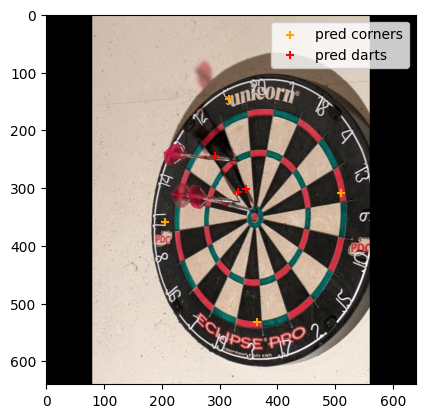

In [177]:
model.eval()
# image, targets = dataset[idx]
images = image_transformed.unsqueeze(0).to(device)
# targets = [targets]
w, h, _ = image.shape      
outputs = model(images)
pred_classes = torch.argmax(outputs["is_dart"], dim=-1)

fig, ax = plt.subplots(1)
ax.imshow(transforms.ToTensor()(image).permute(1,2,0))


pred_corners = outputs["corners"][0].cpu().detach()
pred_darts = outputs["darts"][0][outputs["is_dart"][0, :, 1] > outputs["is_dart"][0, :, 0]].cpu().detach()
all_darts = outputs["darts"][0].cpu().detach()

# Draw points
ax.scatter(pred_corners[:, 0]*w, pred_corners[:, 1]*h, color='orange', s=40, marker='+', label="pred corners")
# ax.scatter(all_darts[:, 0]*w, all_darts[:, 1]*h, color='white', s=10, marker='x', label="all darts")
ax.scatter(pred_darts[:, 0]*w, pred_darts[:, 1]*h, color='red', s=40, marker='+', label="pred darts")
# ax.scatter(targets[0]["corners"][:, 0]*w, targets[0]["corners"][:, 1]*h, color='blue', s=10, marker='o', label="gt corners")
# ax.scatter(targets[0]["darts"][:, 0]*w, targets[0]["darts"][:, 1]*h, color='red', s=10, marker='o', label="gt darts")

# Show plot
plt.legend()
plt.show()